<a href="https://colab.research.google.com/github/Anushkacodesjava/Google--AI-Internship/blob/main/Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8676 - loss: 0.5897 - val_accuracy: 0.8664 - val_loss: 0.2649
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8658 - loss: 0.2247 - val_accuracy: 0.8664 - val_loss: 0.1619
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8637 - loss: 0.1534 - val_accuracy: 0.8664 - val_loss: 0.1398
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8765 - loss: 0.1323 - val_accuracy: 0.9803 - val_loss: 0.1302
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.1112 - val_accuracy: 0.9830 - val_loss: 0.1240
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9906 - loss: 0.1038 - val_accuracy: 0.9857 - val_loss: 0.1188
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9906 - loss: 0.1042 - val_accuracy: 0.9857 - val_loss: 0.1156
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9923 - loss: 0.0911 - val_accuracy: 0.9857 - val_

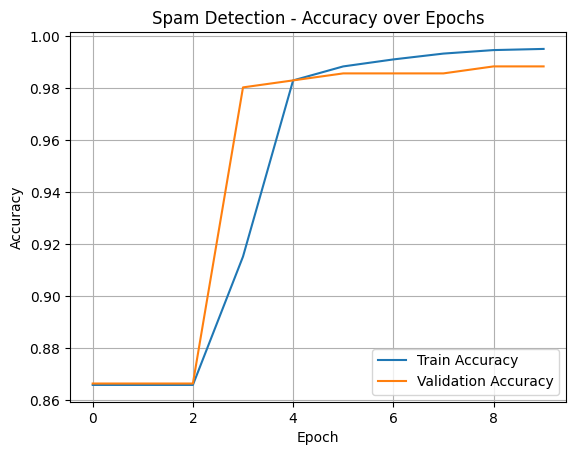


Binary Cross-Entropy is used for binary classification tasks.
It calculates the loss as: - (y * log(p) + (1 - y) * log(1 - p))
Where:
  y = actual label (0 or 1)
  p = predicted probability (output of sigmoid)
It penalizes confident incorrect predictions more heavily.



In [ ]:

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load SMS Spam Dataset
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_table(url, header=None, names=['label', 'message'])

#  Encode labels (ham = 0, spam = 1)
df['label'] = LabelEncoder().fit_transform(df['label'])

#  Split data
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42)

#  TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

#  Build Neural Network Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_vec.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # sigmoid for binary classification
])

#  Compile the Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

#  Train the Model
history = model.fit(X_train_vec, y_train, epochs=10,
                    validation_data=(X_test_vec, y_test), verbose=1)

#  Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Spam Detection - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#  Explanation:
print("""
Binary Cross-Entropy is used for binary classification tasks.
It calculates the loss as: - (y * log(p) + (1 - y) * log(1 - p))
Where:
  y = actual label (0 or 1)
  p = predicted probability (output of sigmoid)
It penalizes confident incorrect predictions more heavily.
""")
